In [1]:
import geopandas as gpd

deaths_df=gpd.read_file("C:\\Users\\KARUN NAGARAJ\\Downloads\\advanced python\\SnowGIS\\SnowGIS\\Cholera_Deaths.shp")
pumps_df=gpd.read_file("C:\\Users\\KARUN NAGARAJ\\Downloads\\advanced python\\SnowGIS\\SnowGIS\\Pumps.shp")

In [2]:
print(deaths_df.head())
print(pumps_df.head())

   Id  Count                       geometry
0   0      3  POINT (529308.741 181031.352)
1   0      2  POINT (529312.164 181025.172)
2   0      1  POINT (529314.382 181020.294)
3   0      1   POINT (529317.38 181014.259)
4   0      4  POINT (529320.675 181007.872)
   Id                       geometry
0   0  POINT (529396.539 181025.063)
1   0  POINT (529192.538 181079.391)
2   0   POINT (529183.74 181193.735)
3   0  POINT (529748.911 180924.207)
4   0  POINT (529613.205 180896.804)


In [3]:
deaths_df.crs

<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.01, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

In [4]:
pumps_df

,Id,geometry
0,0,POINT (529396.539 181025.063)
1,0,POINT (529192.538 181079.391)
2,0,POINT (529183.74 181193.735)
3,0,POINT (529748.911 180924.207)
4,0,POINT (529613.205 180896.804)
5,0,POINT (529453.586 180826.353)
6,0,POINT (529593.727 180660.455)
7,0,POINT (529296.104 180794.849)


<Axes: >

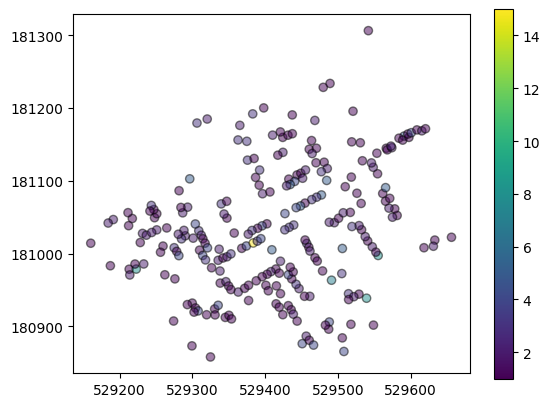

In [4]:
deaths_df.plot(column='Count',alpha=0.5, edgecolor='k', legend=True)

<Axes: >

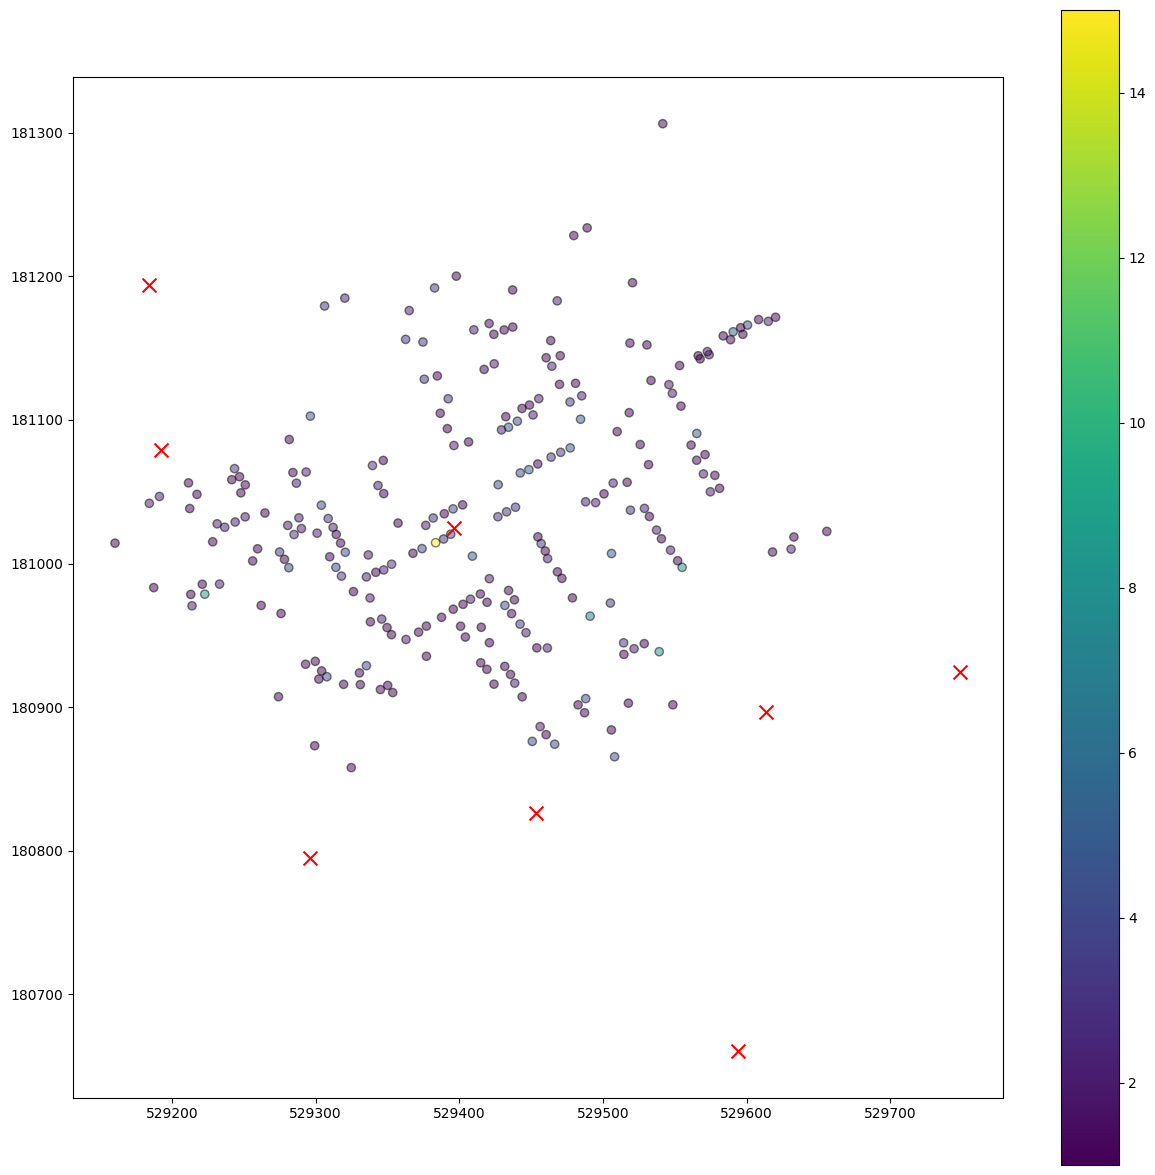

In [6]:
ax=deaths_df.plot(column='Count',figsize=(15,15),alpha=0.5, edgecolor='k', legend=True)
pumps_df.plot(ax=ax,marker='x',color='red', markersize=100)

C:\Users\KARUN NAGARAJ\AppData\Local\Temp\ipykernel_16212\4176450553.py:4: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  ax=deaths_df.plot(column='Count',figsize=(10,10), color='blue', markersize=10, edgecolor='k', legend=True)


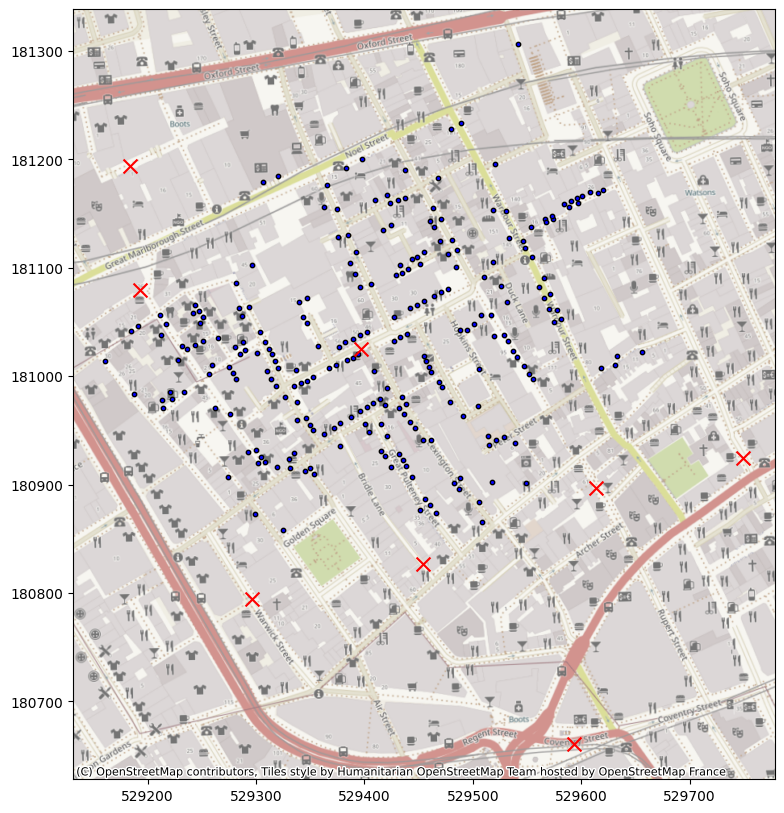

In [13]:

import contextily as ctx
import geopandas as gpd
import matplotlib 
ax=deaths_df.plot(column='Count',figsize=(10,10), color='blue', markersize=10, edgecolor='k', legend=True)
pumps_df.plot(ax=ax,marker='x',color='red', markersize=100)
ctx.add_basemap(ax, crs=deaths_df.crs.to_string(),)

C:\Users\KARUN NAGARAJ\AppData\Local\Temp\ipykernel_16212\1900937889.py:1: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  ax=deaths_df.plot(column='Count',figsize=(10,10), color='blue', markersize=10, edgecolor='k', legend=True)


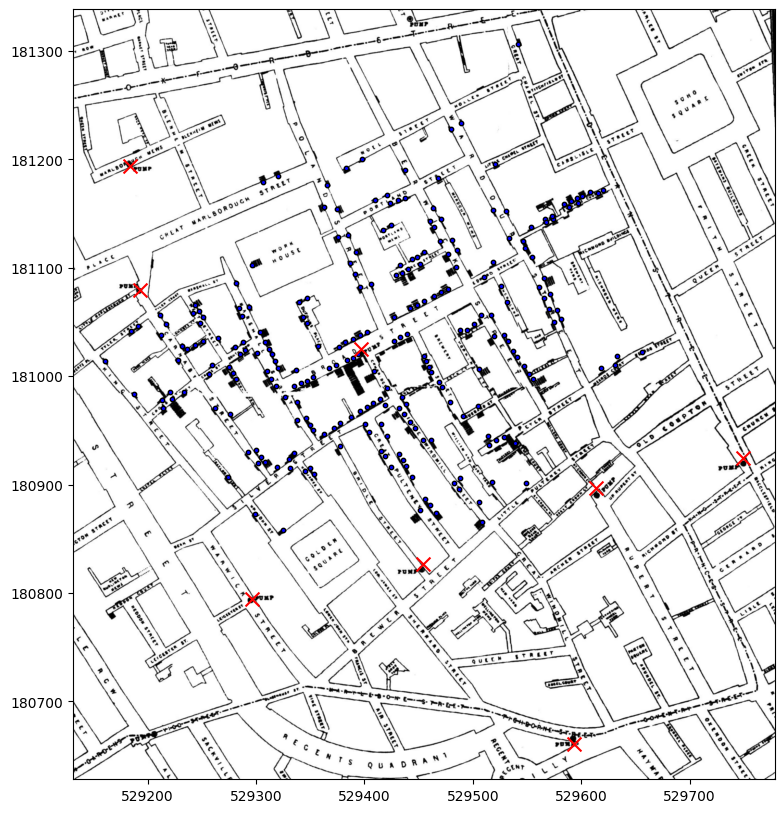

In [16]:
 
ax=deaths_df.plot(column='Count',figsize=(10,10), color='blue', markersize=10, edgecolor='k', legend=True)
pumps_df.plot(ax=ax,marker='x',color='red', markersize=100)
ctx.add_basemap(ax, crs=deaths_df.crs.to_string(),source=r"C:\Users\KARUN NAGARAJ\Downloads\advanced python\SnowGIS\SnowGIS\SnowMap.tif")

C:\Users\KARUN NAGARAJ\AppData\Local\Temp\ipykernel_18928\2377231276.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x,y, label in zip(merged_gdf.geometry.centroid.x, merged_gdf.geometry.centroid.y, merged_gdf['DISTRICT']):


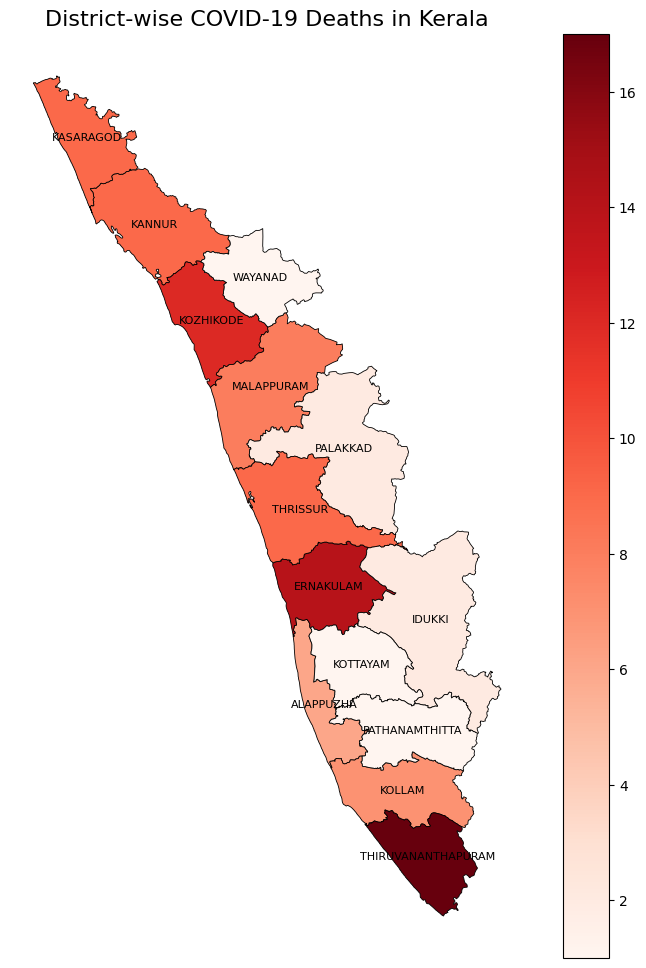

In [5]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Load Kerala district shapefile
kerala_gdf = gpd.read_file("C:\\Users\\KARUN NAGARAJ\\Downloads\\kerala-master\\kerala-master\\shapefiles\\district.shp")

# Load district-level COVID data (all India)
covid_df = pd.read_csv("C:\\Users\\KARUN NAGARAJ\\Downloads\\district_level_latest.csv")

# Filter only Kerala
covid_kerala = covid_df[covid_df["State"] == "Kerala"].copy()

# Standardize district names for accurate merging
kerala_gdf["DISTRICT"] = kerala_gdf["DISTRICT"].str.upper().str.strip()
covid_kerala["District"] = covid_kerala["District"].str.upper().str.strip()

# Merge spatial and COVID data
merged_gdf = kerala_gdf.merge(
    covid_kerala,
    left_on="DISTRICT",
    right_on="District",
    how="left"
)

# Plot district-wise COVID deaths
fig, ax = plt.subplots(figsize=(10, 12))
for x,y, label in zip(merged_gdf.geometry.centroid.x, merged_gdf.geometry.centroid.y, merged_gdf['DISTRICT']):
    ax.text(x, y, label, fontsize=8, ha='center', va='center')
merged_gdf.plot(
    column="Deceased",
    cmap="Reds",
    linewidth=0.6,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("District-wise COVID-19 Deaths in Kerala", fontsize=16)
ax.axis("off")

plt.show()


In [10]:
kerala_gdf = gpd.read_file("C:\\Users\\KARUN NAGARAJ\\Downloads\\kerala-master\\kerala-master\\shapefiles\\district.shp")
print(kerala_gdf.head())

    DISTRICT   ST_NM  ST_CEN_CD  DT_CEN_CD  censuscode  orig_ogc_f  \
0  Alappuzha  Kerala         32         11         598           7   
1  Ernakulam  Kerala         32          8         595         173   
2     Idukki  Kerala         32          9         596         232   
3     Kannur  Kerala         32          2         589         277   
4  Kasaragod  Kerala         32          1         588         288   

                                            geometry  
0  POLYGON ((76.37334 9.83565, 76.37955 9.82888, ...  
1  POLYGON ((76.68924 10.26721, 76.68724 10.2617,...  
2  POLYGON ((77.28895 10.22973, 77.29462 10.21643...  
3  POLYGON ((75.46997 12.30049, 75.48558 12.29131...  
4  POLYGON ((75.41667 12.50166, 75.4224 12.48463,...  
